### **Разведочный анализ данных (EDA)**

**Библиотеки**

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

**Загрузка данных**

In [31]:
data_path = './data/raw/Данные_для_курсовои_Классическое_МО.xlsx'
df = pd.read_excel(data_path, index_col=0)

df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


**Структура данных**

In [32]:
print('Размерность:', df.shape)

Размерность: (1001, 213)


In [33]:
df.dtypes.value_counts()

float64    107
int64      106
Name: count, dtype: int64

**Качество данных**

In [34]:
print('Число inf:', np.isinf(df).sum().sum())

Число inf: 0


In [35]:
print('Число констант:', (df.nunique() == 1).sum())
print('Число дубликатов:', df.duplicated().sum())

Число констант: 18
Число дубликатов: 32


In [36]:
total_missings = df.isnull().sum().sum()

print(
    f'Всего пропусков: {total_missings} '
    f'({total_missings / len(df) * 100:.4f} %)'
)

Всего пропусков: 36 (3.5964 %)


In [37]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

df_missings = missing_counts.to_frame('n_missings')
df_missings['perc_missings'] = (
    df_missings['n_missings'] / len(df) * 100
).round(4)

df_missings.sort_values(by='n_missings', ascending=False)

,n_missings,perc_missings
MaxPartialCharge,3,0.2997
MinPartialCharge,3,0.2997
MaxAbsPartialCharge,3,0.2997
MinAbsPartialCharge,3,0.2997
BCUT2D_MWHI,3,0.2997
BCUT2D_MWLOW,3,0.2997
BCUT2D_CHGHI,3,0.2997
BCUT2D_CHGLO,3,0.2997
BCUT2D_LOGPHI,3,0.2997
BCUT2D_LOGPLOW,3,0.2997


**Очистка данных**

In [38]:
unique_counts = df.nunique()
const_counts = unique_counts[unique_counts == 1]

df = df.drop(columns=const_counts.index)

print('Число констант:', (df.nunique() == 1).sum())

Число констант: 0


In [39]:
df = df.drop_duplicates()

print('Число дубликатов:', df.duplicated().sum())

Число дубликатов: 0


In [40]:
df = df.fillna(df.median())

print('Всего пропусков:', df.isnull().sum().sum())

Всего пропусков: 0


**Анализ целевых переменных**

In [41]:
target_cols = ['IC50, mM', 'CC50, mM', 'SI']

df[target_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
"IC50, mM",969.0,220.726223,397.172441,0.003517,12.515396,45.338355,231.373089,4128.529377
"CC50, mM",969.0,586.419908,633.624464,0.700808,99.999345,424.166213,891.776925,4538.976189
SI,969.0,73.967907,695.564665,0.011489,1.488095,3.900000,16.375000,15620.600000


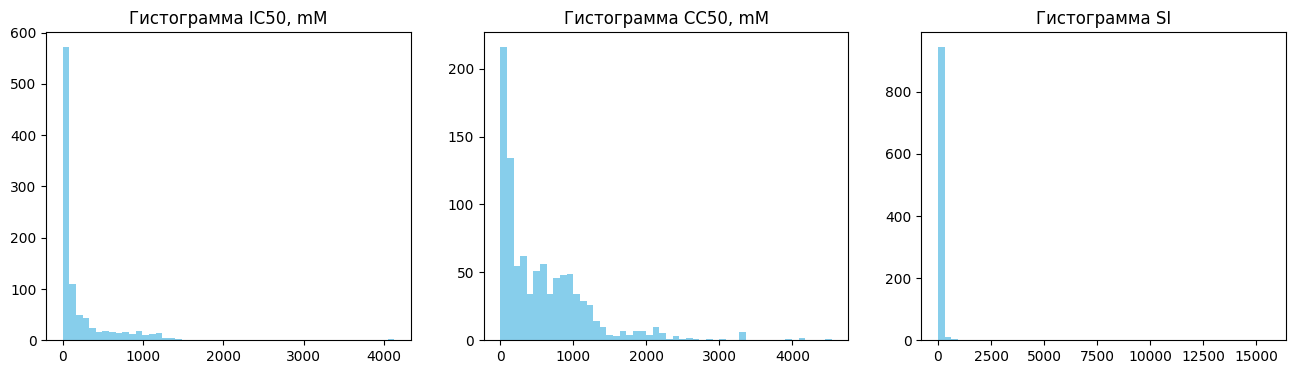

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, target_cols):
    
    ax.hist(df[col], bins=50, color='skyblue')
    ax.set_title(f'Гистограмма {col}')


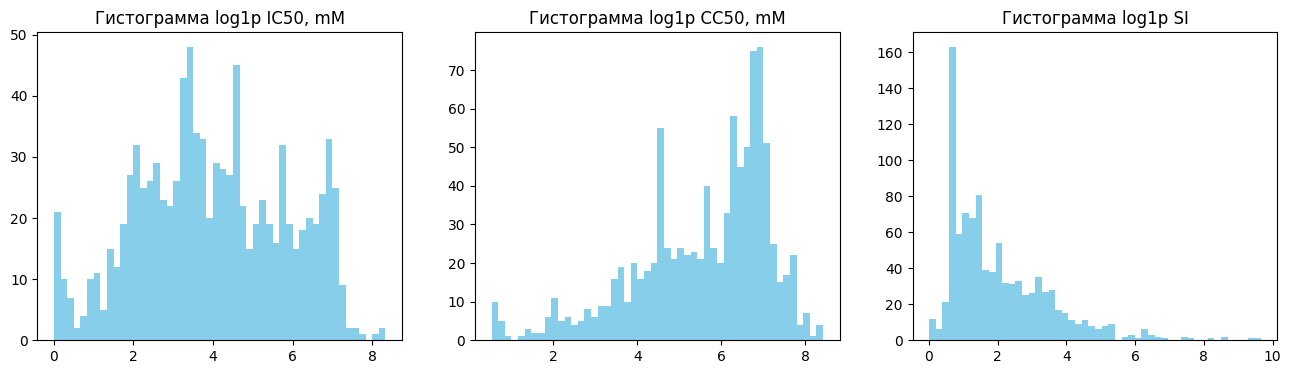

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, target_cols):
    
    data = np.log1p(df[col])
    
    ax.hist(data, bins=50, color='skyblue')
    ax.set_title(f'Гистограмма log1p {col}')


In [44]:
print('Асимметрия до преобразования:')
print(
    df[target_cols].skew()
    .to_string()
)
print()

print('Асимметрия после log1p:')
print(
    np.log1p(df[target_cols]).skew()
    .to_string()
)

Асимметрия до преобразования:
IC50, mM     3.757993
CC50, mM     1.996707
SI          17.728174

Асимметрия после log1p:
IC50, mM   -0.020430
CC50, mM   -0.942520
SI          1.461633


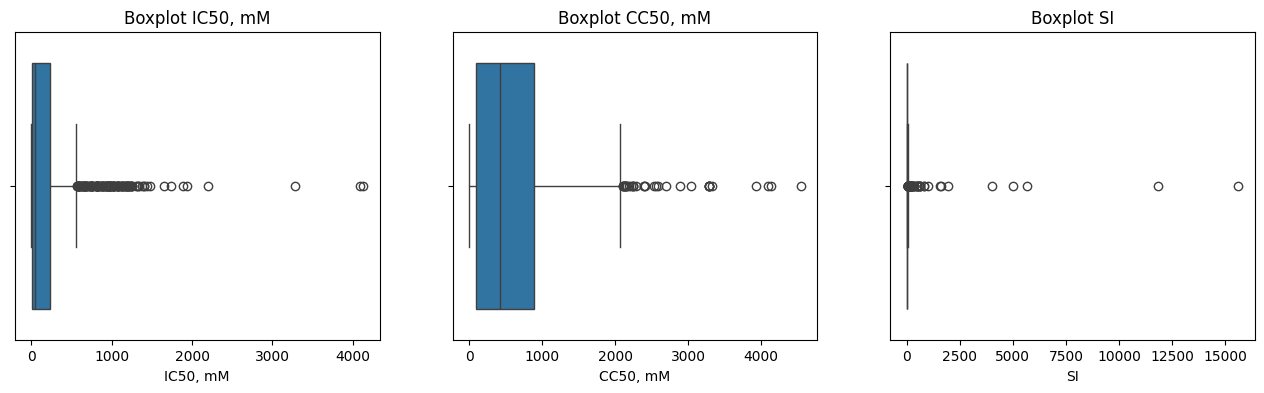

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, target_cols):
    
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f'Boxplot {col}')


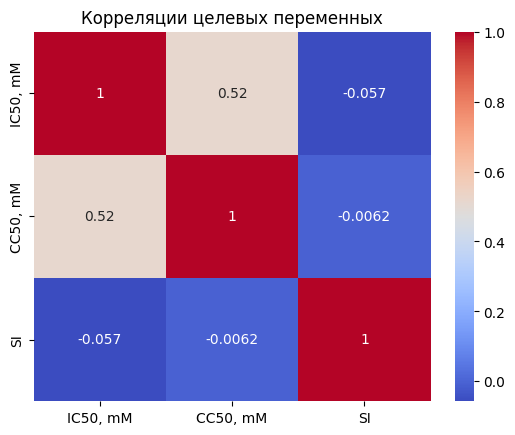

In [46]:
sns.heatmap(
    df[target_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Корреляции целевых переменных');

**Анализ признаков**

In [47]:
df_features = df.drop(columns=target_cols)

print('Число признаков:', df_features.shape[1])

Число признаков: 192


In [48]:
df_desc = df_features.describe().T[['mean','std','min','max']]

df_desc.sort_values(by='std')

,mean,std,min,max
fr_Ar_COO,1.031992e-03,3.212463e-02,0.000000,1.000000e+00
fr_term_acetylene,1.031992e-03,3.212463e-02,0.000000,1.000000e+00
fr_tetrazole,1.031992e-03,3.212463e-02,0.000000,1.000000e+00
fr_HOCCN,1.031992e-03,3.212463e-02,0.000000,1.000000e+00
fr_aldehyde,3.095975e-03,5.558398e-02,0.000000,1.000000e+00
...,...,...,...,...
HeavyAtomMolWt,3.275719e+02,1.220372e+02,100.076000,8.563930e+02
ExactMolWt,3.511597e+02,1.272498e+02,110.073165,9.042485e+02
MolWt,3.514861e+02,1.273882e+02,110.156000,9.047770e+02
BertzCT,7.648316e+02,4.374651e+02,113.625488,2.263926e+03


In [49]:
df_desc.sort_values(by='std', ascending=False)

,mean,std,min,max
Ipc,4.991263e+10,1.276529e+12,107.107191,3.951781e+13
BertzCT,7.648316e+02,4.374651e+02,113.625488,2.263926e+03
MolWt,3.514861e+02,1.273882e+02,110.156000,9.047770e+02
ExactMolWt,3.511597e+02,1.272498e+02,110.073165,9.042485e+02
HeavyAtomMolWt,3.275719e+02,1.220372e+02,100.076000,8.563930e+02
...,...,...,...,...
fr_aldehyde,3.095975e-03,5.558398e-02,0.000000,1.000000e+00
fr_Ar_COO,1.031992e-03,3.212463e-02,0.000000,1.000000e+00
fr_HOCCN,1.031992e-03,3.212463e-02,0.000000,1.000000e+00
fr_tetrazole,1.031992e-03,3.212463e-02,0.000000,1.000000e+00


In [50]:
for target_col in target_cols:
    
    corr = df_features.corrwith(df[target_col]).abs()
    high_corr = corr[corr > 0.9]
    
    print(
        f'Число сильно коррилирующих признаков с {target_col}:',
        len(high_corr)
    )


Число сильно коррилирующих признаков с IC50, mM: 0
Число сильно коррилирующих признаков с CC50, mM: 0
Число сильно коррилирующих признаков с SI: 0


In [51]:
df_corr = df_features.corr().abs()

corr_mask = np.triu(np.ones(df_corr.shape), k=1).astype(bool)
df_corr = df_corr.where(corr_mask)

df_high_corr = df_corr.stack()
df_high_corr = df_high_corr[df_high_corr > 0.9]

print('Сильно коррилирующие признаки:')
print(
    df_high_corr
    .sort_values(ascending=False)
    .to_string()
)

Сильно коррилирующие признаки:
MaxAbsEStateIndex        MaxEStateIndex             1.000000
fr_Ar_NH                 fr_Nhpyrrole               1.000000
NumAromaticCarbocycles   fr_benzene                 1.000000
fr_phenol                fr_phenol_noOrthoHbond     1.000000
fr_COO                   fr_COO2                    1.000000
MolWt                    ExactMolWt                 0.999999
Chi1                     HeavyAtomCount             0.998736
MolWt                    HeavyAtomMolWt             0.996861
HeavyAtomMolWt           ExactMolWt                 0.996830
Chi0                     HeavyAtomCount             0.995968
NumValenceElectrons      Chi0                       0.994847
LabuteASA                HeavyAtomCount             0.994362
Chi1                     LabuteASA                  0.992830
Chi0n                    Chi0v                      0.992684
Chi0                     Chi1                       0.990931
fr_Ar_OH                 fr_phenol                  0.

**Подготовка данных**

In [52]:
df_prep = df.copy()

print('Размерность:', df_prep.shape)

Размерность: (969, 195)


In [53]:
# Удаление сильно коррилирующих признаков (> 0.99)

df_features = df_prep.drop(columns=target_cols)

df_corr = df_features.corr().abs()

corr_mask = np.triu(np.ones(df_corr.shape), k=1).astype(bool)
df_corr = df_corr.where(corr_mask)

to_drop = [col for col in df_corr.columns if any(df_corr[col] > 0.99)]

df_prep = df_prep.drop(columns=to_drop)

print('Удалено признаков:', len(to_drop))
print('Осталось признаков:', df_prep.shape[1])

Удалено признаков: 14
Осталось признаков: 181


In [54]:
# log1p преобразование целевых переменных

df_prep['IC50_log'] = np.log1p(df_prep['IC50, mM'])
df_prep['CC50_log'] = np.log1p(df_prep['CC50, mM'])
df_prep['SI_log'] = np.log1p(df_prep['SI'])

print('Размерность:', df_prep.shape)

Размерность: (969, 184)


In [55]:
# Подготовка целевых переменных для классификации

ic50_median = df_prep['IC50, mM'].median()
cc50_median = df_prep['CC50, mM'].median()
si_median = df_prep['SI'].median()

df_prep['IC50_above_median'] = (df_prep['IC50, mM'] > ic50_median).astype(int)
df_prep['CC50_above_median'] = (df_prep['CC50, mM'] > cc50_median).astype(int)
df_prep['SI_above_median'] = (df_prep['SI'] > si_median).astype(int)
df_prep['SI_above_8'] = (df_prep['SI'] > 8).astype(int)

print('Размерность:', df_prep.shape)

Размерность: (969, 188)


*Сохранение признаков и целевых переменных*

In [56]:
X = df_prep.drop(columns=[
    'IC50, mM', 'CC50, mM', 'SI',
    'IC50_log', 'CC50_log', 'SI_log',
    'IC50_above_median', 'CC50_above_median',
    'SI_above_median', 'SI_above_8'
])

X.to_csv('./data/processed/X.csv')

print('Признаки сохранены')

Признаки сохранены


In [57]:
reg_targets = {
    'y_ic50': ['IC50, mM', 'IC50_log'],
    'y_cc50': ['CC50, mM', 'CC50_log'],
    'y_si': ['SI', 'SI_log'],
}

for name, col in reg_targets.items():
    df_prep[col].to_csv(f'./data/processed/{name}.csv')
    
print('Целевые переменные для регрессии сохранены')

Целевые переменные для регрессии сохранены


In [58]:
clf_targets = {
    'y_ic50_cls': 'IC50_above_median',
    'y_cc50_cls': 'CC50_above_median',
    'y_si_cls': 'SI_above_median',
    'y_si_8_cls': 'SI_above_8'
}

for name, col in clf_targets.items():
    df_prep[[col]].to_csv(f'./data/processed/{name}.csv')
    
print('Целевые переменные для классификации сохранены')

Целевые переменные для классификации сохранены
